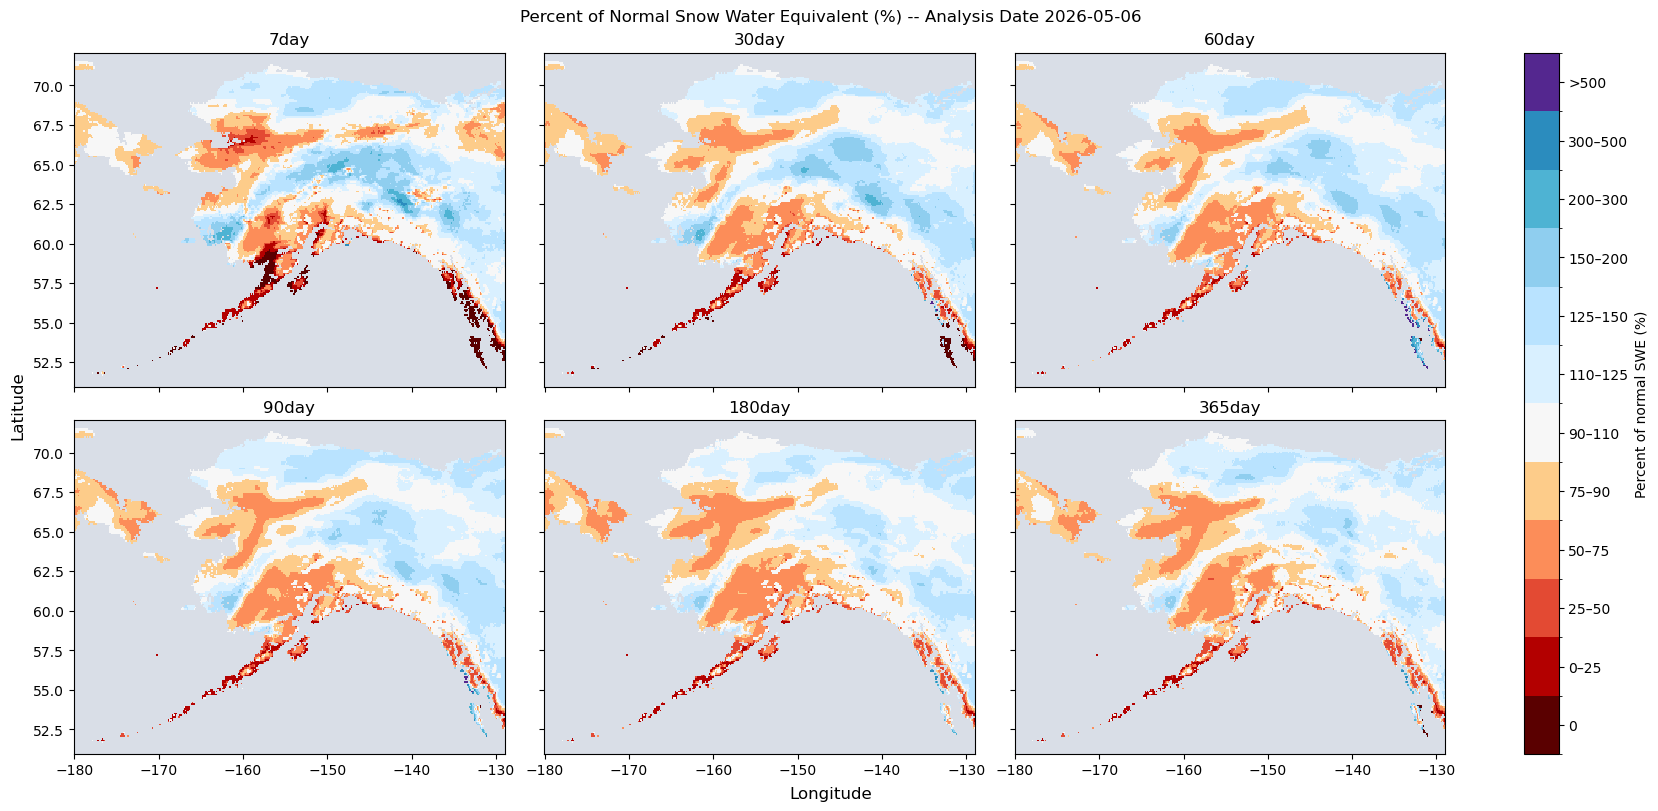

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.colors import BoundaryNorm, ListedColormap

data_dir = Path("snap/drought_outputs")

all_files = [
    Path("snap/drought_outputs/drought_indices_1day.nc"),
    Path("snap/drought_outputs/drought_indices_7day.nc"),
    Path("snap/drought_outputs/drought_indices_30day.nc"),
    Path("snap/drought_outputs/drought_indices_60day.nc"),
    Path("snap/drought_outputs/drought_indices_90day.nc"),
    Path("snap/drought_outputs/drought_indices_180day.nc"),
    Path("snap/drought_outputs/drought_indices_365day.nc"),
]

variable_key = "pnswe"
long_name = "Percent of Normal Snow Water Equivalent (%)"
analysis_date = "2026-05-06"

# Discrete percent-of-normal SWE categories.
# Centered on 100% = normal, with expanded wet-side bins
# because maxima can exceed 2000%.
bounds = [
    -0.5,
    0.5,
    25,
    50,
    75,
    90,
    110,
    125,
    150,
    200,
    300,
    500,
    2500,
]

colors = [
    "#5a0000",  # exactly / nearly 0
    "#b30000",  # 0 to 25
    "#e34a33",  # 25 to 50
    "#fc8d59",  # 50 to 75
    "#fdcc8a",  # 75 to 90
    "#f7f7f7",  # 90 to 110
    "#d9f0ff",  # 110 to 125
    "#b9e3ff",  # 125 to 150
    "#8fceef",  # 150 to 200
    "#4eb3d3",  # 200 to 300
    "#2b8cbe",  # 300 to 500
    "#54278f",  # >500
]

cmap = ListedColormap(colors)
cmap.set_bad("#d9dee7")  # ocean / masked cells

norm = BoundaryNorm(bounds, cmap.N, clip=True)

cbar_labels = [
    "0",
    "0–25",
    "25–50",
    "50–75",
    "75–90",
    "90–110",
    "110–125",
    "125–150",
    "150–200",
    "200–300",
    "300–500",
    ">500",
]

# Bin-center tick positions for a categorical colorbar
cbar_ticks = [
    0,
    12.5,
    37.5,
    62.5,
    82.5,
    100,
    117.5,
    137.5,
    175,
    250,
    400,
    1500,
]

short_window_files = [all_files[0]]
long_window_files = all_files[1::]


def open_nc(path: str | Path) -> xr.Dataset:
    """Open a NetCDF file with decoding enabled."""
    return xr.open_dataset(path)


def plot_variable_across_files(
    paths: list[str | Path],
    figsize_per_panel: tuple[float, float] = (5.5, 4.0),
    save_path: str | Path | None = None,
) -> plt.Figure:
    """Compare percent-of-normal SWE across multiple NetCDF files."""

    ncols = 3
    nrows = 2

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        constrained_layout=True,
        squeeze=False,
        sharex=True,
        sharey=True,
    )

    opened: list[tuple[Path, xr.Dataset]] = []

    for path in paths:
        p = Path(path)
        ds = open_nc(p)
        opened.append((p, ds))

    mesh = None

    for ax, (path, ds) in zip(axes.flat, opened, strict=False):
        # Mask ocean using smd, assuming smd is NaN over ocean
        da = ds[variable_key].where(ds["smd"].notnull())

        lon = ds["longitude"].values
        lat = ds["latitude"].values

        mesh = ax.pcolormesh(
            lon,
            lat,
            da.values,
            shading="auto",
            cmap=cmap,
            norm=norm,
        )

        ax.set_title(Path(path).stem.split("_")[-1])
        ax.label_outer()
        ax.set_facecolor("white")

    if mesh is None:
        raise ValueError("No input files were provided.")

    fig.supxlabel("Longitude")
    fig.supylabel("Latitude")

    cbar = fig.colorbar(
        mesh,
        ax=axes.ravel().tolist(),
        boundaries=bounds,
        ticks=cbar_ticks,
        spacing="uniform",
    )

    cbar.set_ticklabels(cbar_labels)
    cbar.set_label("Percent of normal SWE (%)")

    fig.suptitle(
        f"{long_name} -- Analysis Date {analysis_date}",
        fontsize=12,
    )

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

plot_variable_across_files(long_window_files, save_path="pnswe.png")